                                        Project 
End-to-End E-commerce Intelligence System: Building a Customer 360 Analytics Framework

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Load all dataset from local

order_item = pd.read_csv(r"C:\Users\agayen\Downloads\python_project_aiml_logicmojo\python_project_aiml_logicmojo_dataset\order_item.csv")
print('Before coloumn standardization\n') 
order_item.info()
# In the order_item table, column standardization is required for order_item_id. Additionally, the shipping_limit_date 
#column is currently in object (string) format and needs to be converted to datetime format, as machine learning 
#models cannot interpret raw text-based date values.

order_item.rename(columns = {'order_item_id' : 'order_items' }, inplace = True)
order_item['shipping_limit_date'] = pd.to_datetime(order_item['shipping_limit_date'], dayfirst = True)
#order_item['shipping_limit_date'] = pd.to_datetime(order_item['shipping_limit_date'], format='%d-%m-%Y %H:%M').dt.strftime('%Y-%m-%d %H:%M:%S')
print('\nAfter coloumn standardization\n')
order_item.info()

# Checking null value in order_item table
order_item.isnull().sum()

# order_item table "order_id" is primary key, so checking duplicate value is present on that column or not
order_item['order_id'].duplicated().any()
# Dropping duplicate value
order_item = order_item.drop_duplicates(subset=['order_id'])

Before coloumn standardization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

After coloumn standardization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_items     

In [2]:
orders = pd.read_csv(r"C:\Users\agayen\Downloads\python_project_aiml_logicmojo\python_project_aiml_logicmojo_dataset\orders.csv")

print('Before coloumn standardization\n') 
orders.info()
# In the orders table, column standardization is required for order_approved_at. Additionally, few date column
#column is currently in object (string) format and needs to be converted to datetime format, as machine learning 
#models cannot interpret raw text-based date values.

orders.rename(columns = {'order_approved_at' : 'order_approved_date' }, inplace = True)
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], format='%d-%m-%Y %H:%M')
orders['order_approved_date'] = pd.to_datetime(orders['order_approved_date'], format='%d-%m-%Y %H:%M')
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'], format='%d-%m-%Y %H:%M')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], format='%d-%m-%Y %H:%M')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], format='%d-%m-%Y %H:%M')

print('\nAfter coloumn standardization\n')
orders.info()

# Checking null value in orders table
orders.isnull().sum()

# Dropping null rows beacuse < 2% rows have null value
orders = orders.dropna(subset = ['order_approved_date', 'order_delivered_carrier_date', 'order_delivered_customer_date'])

# orders table "order_id" is primary key, so checking duplicate value is present on that column or not
orders['order_id'].duplicated().any()



Before coloumn standardization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

After coloumn standardization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------            

np.False_

In [3]:
payments = pd.read_csv(r"C:\Users\agayen\Downloads\python_project_aiml_logicmojo\python_project_aiml_logicmojo_dataset\payments.csv")

print('Before coloumn standardization\n') 
payments.info()

# Checking null value in payments table
payments.isnull().sum()

# payments table "order_id" is primary key, so checking duplicate value is present on that column or not
payments['order_id'].duplicated().any()

# Dropping duplicate value
payments = payments.drop_duplicates(subset=['order_id'])

Before coloumn standardization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [4]:
products = pd.read_csv(r"C:\Users\agayen\Downloads\python_project_aiml_logicmojo\python_project_aiml_logicmojo_dataset\products.csv")

print('Before coloumn standardization\n') 
products.info()

# Checking null value in products table
products.isnull().sum()

#Filling null values on each column
products['product_category_name'] = products['product_category_name'].fillna('Not Available')
products['product_name_lenght'] = products['product_name_lenght'].fillna(products['product_name_lenght'].mean())
products['product_description_lenght'] = products['product_description_lenght'].fillna(products['product_name_lenght'].mean())
products['product_photos_qty'] = products['product_photos_qty'].fillna(products['product_name_lenght'].mode()[0])

# Dropped rows beacuse only 2 row have null value
products = products.dropna(subset = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'])

# products table "product_id" is primary key, so checking duplicate value is present on that column or not
products['product_id'].duplicated().any()

Before coloumn standardization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


np.False_

In [7]:
reviews = pd.read_csv(r"C:\Users\agayen\Downloads\python_project_aiml_logicmojo\python_project_aiml_logicmojo_dataset\reviews.csv")

print('Before coloumn standardization\n') 
reviews.info()

# In the reviews table few date column is currently in object (string) format and needs to be converted to 
#datetime format, as machine learning models cannot interpret raw text-based date values.

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

# review_comment_title and review_comment_message columns dropped becuase 60% have null value
reviews = reviews.drop(columns = ['review_comment_title', 'review_comment_message'])

print('\nAfter coloumn standardization\n')
reviews.info()

# Checking null value in reviews table
reviews.isnull().sum()

# reviews table "review_id" is primary key, so checking duplicate value is present on that column or not
reviews['review_id'].duplicated().any()

Before coloumn standardization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB

After coloumn standardization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order

np.True_

In [8]:
sellers = pd.read_csv(r"C:\Users\agayen\Downloads\python_project_aiml_logicmojo\python_project_aiml_logicmojo_dataset\sellers.csv")

print('Before coloumn standardization\n') 
sellers.info()

# Checking duplicate value based on seller_id
sellers['seller_id'].duplicated().any()

#Checking null value
sellers.isna().sum()

Before coloumn standardization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [9]:
category_translation = pd.read_csv(r"C:\Users\agayen\Downloads\python_project_aiml_logicmojo\python_project_aiml_logicmojo_dataset\category_translation.csv")

print('Before coloumn standardization\n') 
category_translation.info()

# Checking duplicate value based on seller_id
category_translation['product_category_name_english'].duplicated().any()

#Checking null value
category_translation.isna().sum()

Before coloumn standardization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


product_category_name            0
product_category_name_english    0
dtype: int64

In [10]:
customers = pd.read_csv(r"C:\Users\agayen\Downloads\python_project_aiml_logicmojo\python_project_aiml_logicmojo_dataset\customers.csv")
print('Before coloumn standardization\n') 
customers.info()

# Checking duplicate value based on seller_id
customers['customer_id'].duplicated().any()

#Checking null value
customers.isna().sum()

Before coloumn standardization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [11]:
location = pd.read_csv(r"C:\Users\agayen\Downloads\python_project_aiml_logicmojo\python_project_aiml_logicmojo_dataset\location.csv")

print('Before coloumn standardization\n') 
location.info()

# Checking duplicate value based on seller_id
location.duplicated().any()

#We have identified duplicate value in location table and dropping those duplicate value
location = location.drop_duplicates(keep=False)

#Checking null value
location.isna().sum()

Before coloumn standardization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

#####Constructing a Master Dataset by merging multiple tables###

In [22]:
#Merging table

order_customer = pd.merge(orders, customers, on = 'customer_id', how = 'left')
order_orderiteam = pd.merge(order_customer, order_item, on = 'order_id', how = 'left')
orderiteam_product = pd.merge(order_orderiteam, products, on ='product_id', how = 'outer')
order_payment = pd.merge(orderiteam_product, payments, on ='order_id', how = 'outer')
order_review = pd.merge(order_payment, reviews, on='order_id', how = 'outer')
order_item_seller = pd.merge(order_review, sellers, on='seller_id', how = 'left')
master_data = pd.merge(order_item_seller, category_translation, on='product_category_name', how = 'left')

master_data.info()

# Checking Null value
master_data.isna().sum()

#Dropping null row where null value have less then 1%
master_data = master_data.dropna(subset = ['order_items', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 
                                        'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
                                        'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'payment_sequential',
                                        'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_creation_date',
                                        'review_answer_timestamp', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name_english'])

master_data.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101794 entries, 0 to 101793
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99992 non-null  object        
 1   customer_id                    96990 non-null  object        
 2   order_status                   96990 non-null  object        
 3   order_purchase_timestamp       96990 non-null  datetime64[ns]
 4   order_approved_date            96990 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96990 non-null  datetime64[ns]
 6   order_delivered_customer_date  96990 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96990 non-null  datetime64[ns]
 8   customer_unique_id             96990 non-null  object        
 9   customer_zip_code_prefix       96990 non-null  float64       
 10  customer_city                  96990 non-null  object        
 11  customer_stat

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_date,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_installments,payment_value,review_id,review_score,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:00,2017-09-13 09:45:00,2017-09-19 18:34:00,2017-09-20 23:43:00,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013.0,...,2.0,72.19,97ca439bc427b48bc1cd7177abe71365,5.0,2017-09-21,2017-09-22 10:57:03,27277.0,volta redonda,SP,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:00,2017-04-26 11:05:00,2017-05-04 14:35:00,2017-05-12 16:04:00,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775.0,...,3.0,259.83,7b07bacd811c4117b742569b04ce3580,4.0,2017-05-13,2017-05-15 11:34:13,3471.0,sao paulo,SP,pet_shop
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:00,2018-01-14 14:48:00,2018-01-16 12:36:00,2018-01-22 13:19:00,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661.0,...,5.0,216.87,0c5b33dea94867d1ac402749e5438e8b,5.0,2018-01-23,2018-01-23 16:06:31,37564.0,borda da mata,MG,furniture_decor


                                ###Feature Engineering###

In [27]:
#Total order value (aggregated from order_items or payments) 
master_data['total_order_value'] = master_data.groupby('customer_id')['payment_value'].transform('sum')
#Delivery time (order purchase to delivery date)
master_data['delevery_time'] = master_data['order_delivered_customer_date'] - master_data['order_purchase_timestamp']
#Number of items per order 
master_data['number_of_item'] = master_data.groupby('order_id')['order_id'].transform('count')
#Customer purchase frequency 
master_data['customer_purchase_frequency'] = master_data.groupby('customer_id')['order_id'].transform('count')
#Customer Lifetime Value
master_data['customer_lifetime_value'] = master_data.groupby('customer_unique_id')['price'].transform('sum')
#Average order value per customer 
master_data['customer_average_order_value'] = master_data.groupby('customer_unique_id')['price'].transform('mean')
master_data[['order_id', 'total_order_value', 'delevery_time', 'number_of_item', 'customer_purchase_frequency', 'customer_lifetime_value', 'customer_average_order_value']].head(3)
                                                                                                                                                               

,order_id,total_order_value,delevery_time,number_of_item,customer_purchase_frequency,customer_lifetime_value,customer_average_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,7 days 14:44:00,1,1,58.90,58.90
1,00018f77f2f0320c557190d7a144bdd3,259.83,16 days 05:11:00,1,1,252.78,126.39
2,000229ec398224ef6ca0657da4fc703e,216.87,7 days 22:46:00,1,1,199.00,199.00


                        ####Exploratory Data Analysis (EDA)####

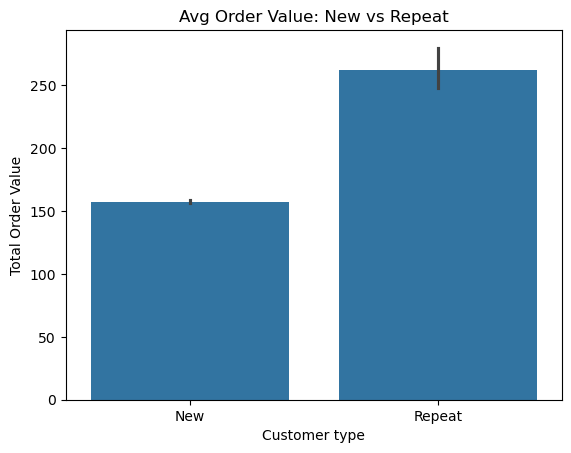

In [32]:
#Adding customer type column on master dataset
master_data['customer_type'] = master_data['customer_purchase_frequency'].apply(
    lambda x: 'New' if x == 1 else 'Repeat'
)

#Analisys on new vs repeat customer
sns.barplot(x='customer_type', y='total_order_value', data=master_data)
plt.title('Avg Order Value: New vs Repeat')
plt.xlabel('Customer type')
plt.ylabel('Total Order Value')
plt.show()

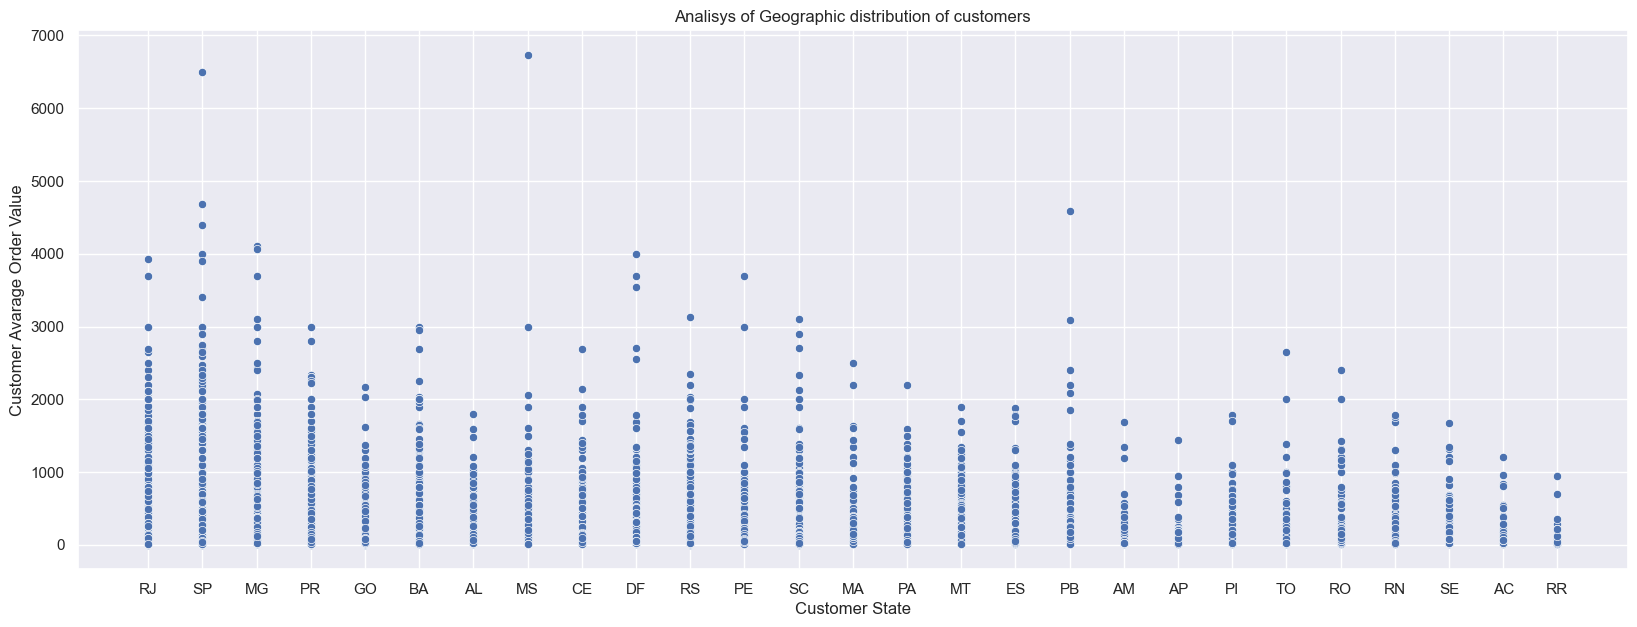

In [38]:
#Analisys of Geographic distribution of customers
plt.title('Analisys of Geographic distribution of customers')
sns.set(rc={"figure.figsize": (20, 7)})
sns.scatterplot(x = 'customer_state', y = 'customer_average_order_value', data=master_data)
plt.xlabel('Customer State')
plt.ylabel('Customer Avarage Order Value')
plt.show()

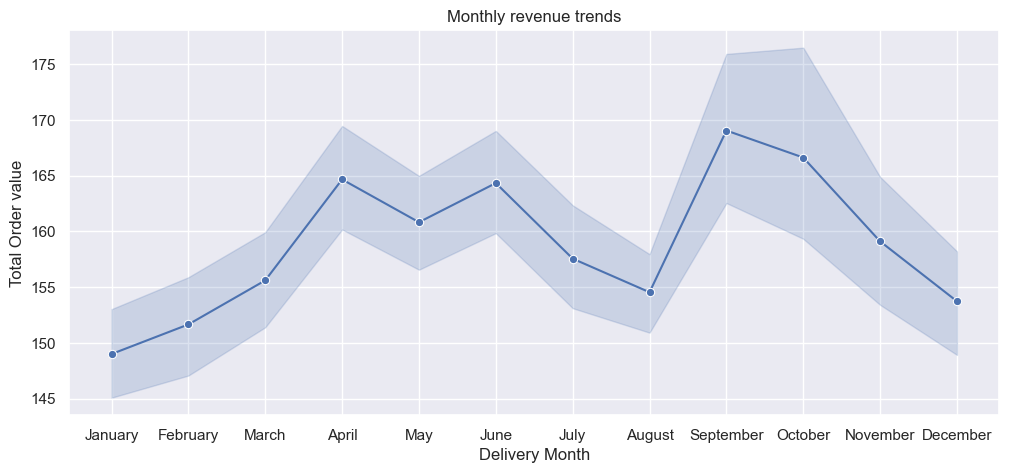

In [40]:
#Monthly revenue trends 
master_data["delivery_month"] = master_data["order_delivered_customer_date"].dt.month_name()
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
master_data["delivery_month"] = pd.Categorical(master_data["delivery_month"], categories=month_order, ordered=True)
plt.title('Monthly revenue trends')
sns.set(rc={"figure.figsize": (12, 5)})
sns.lineplot(x="delivery_month", y="total_order_value", data=master_data, marker="o")
plt.xlabel('Delivery Month')
plt.ylabel('Total Order value')
plt.show()

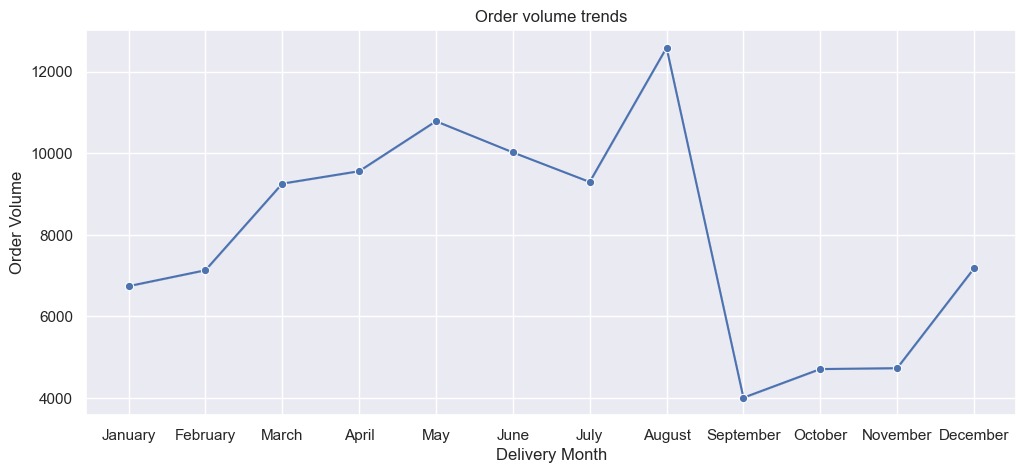

In [41]:
#Order volume trends 
master_data['order_volume'] = master_data.groupby('delivery_month', observed=True)['number_of_item'].transform('sum')
plt.title('Order volume trends')
sns.set(rc={"figure.figsize": (12, 5)})
sns.lineplot(x="delivery_month", y="order_volume", data=master_data, marker="o")
plt.xlabel('Delivery Month')
plt.ylabel('Order Volume')
plt.show()

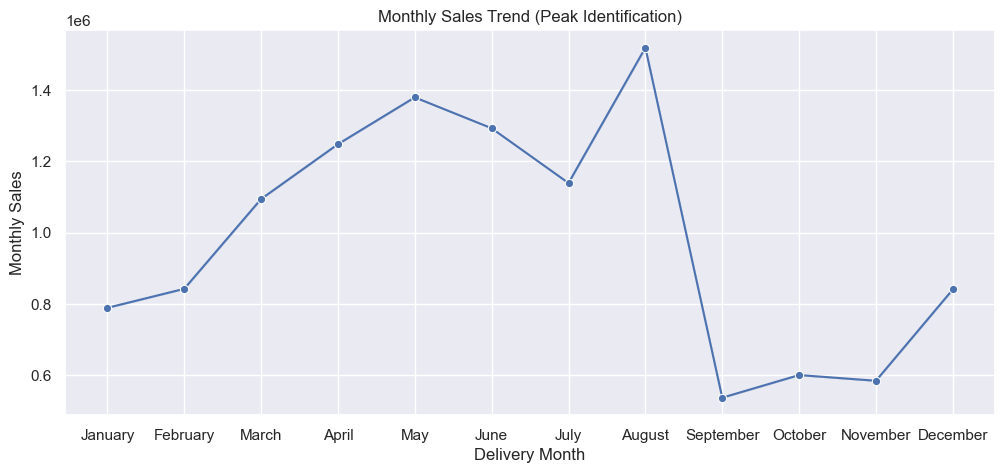

In [42]:
#Peak sales periods
master_data['monthly_sales'] = master_data.groupby('delivery_month', observed=True)['price'].transform('sum')
plt.figure(figsize=(12,5))
sns.lineplot(x="delivery_month", y="monthly_sales", data=master_data, marker="o")
plt.title("Monthly Sales Trend (Peak Identification)")
plt.xlabel('Delivery Month')
plt.ylabel('Monthly Sales')
plt.show()

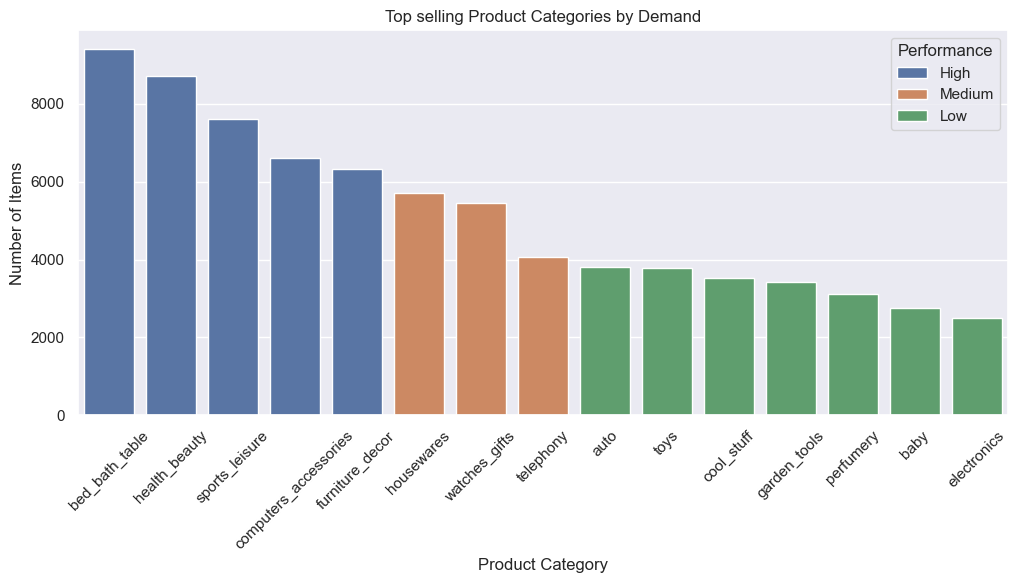

In [69]:
#Top-selling product categories 
product_categories = (master_data.groupby('product_category_name_english')['number_of_item'].sum().reset_index().sort_values(by='number_of_item', ascending=False))
product_categories['product_performance'] = product_categories['number_of_item'].apply(
    lambda x: 'High' if x > 6000 else ('Medium' if x > 4000 else 'Low')
)

top_categories = product_categories.sort_values(by='number_of_item', ascending=False).head(15)

plt.figure(figsize=(12,5))
sns.barplot(x='product_category_name_english', y='number_of_item', data=top_categories, hue='product_performance')
plt.title("Top selling Product Categories by Demand")
plt.xlabel("Product Category")
plt.ylabel("Number of Items")
plt.xticks(rotation=45)
plt.legend(title="Performance")
plt.show()

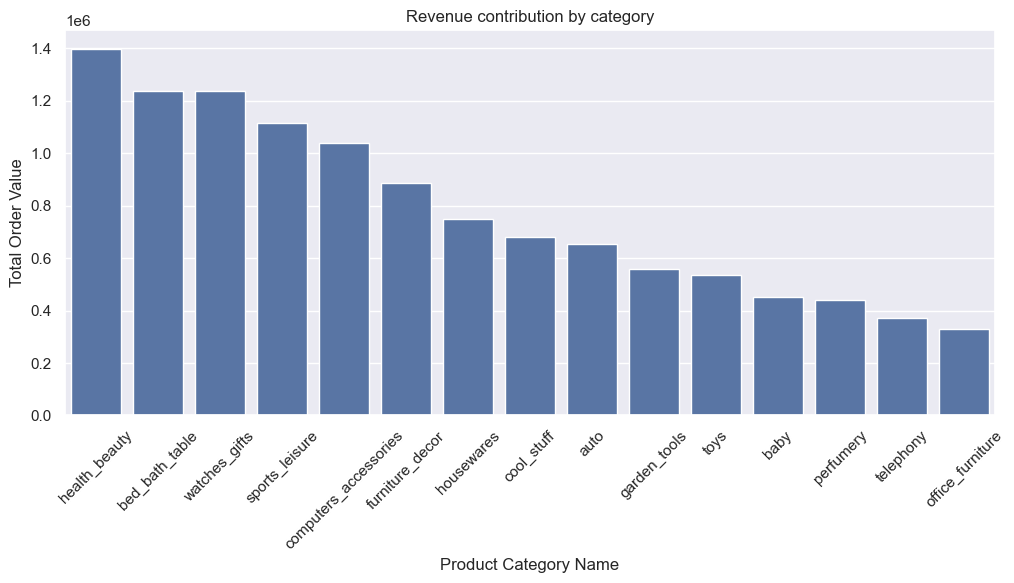

In [82]:
#Revenue contribution by category
revenue_category = (master_data.groupby('product_category_name_english')['total_order_value'].sum().reset_index().sort_values(by='total_order_value', ascending=False))

top_revenew_categories = revenue_category.sort_values(by='total_order_value', ascending=False).head(15)

plt.figure(figsize=(12,5))
sns.barplot(x='product_category_name_english', y='total_order_value', data=top_revenew_categories)
plt.title("Revenue contribution by category")
plt.xlabel("Product Category Name")
plt.ylabel("Total Order Value")
plt.xticks(rotation=45)
plt.show()

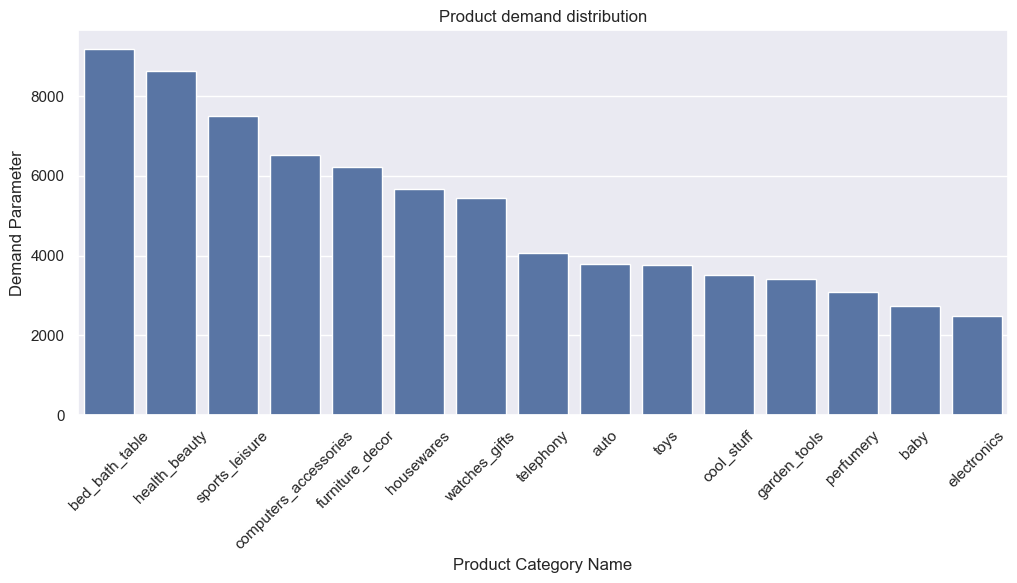

In [89]:
#Product demand distribution
product_demand = (master_data.groupby('product_category_name_english').size().reset_index(name='demand'))
product_demand = product_demand.sort_values(by='demand', ascending=False).head(15)

plt.figure(figsize=(12,5))
sns.barplot(x='product_category_name_english', y='demand', data=product_demand)
plt.title("Product demand distribution")
plt.xlabel("Product Category Name")
plt.ylabel("Demand Parameter")
plt.xticks(rotation=45)
plt.show()


Top-performing sellers


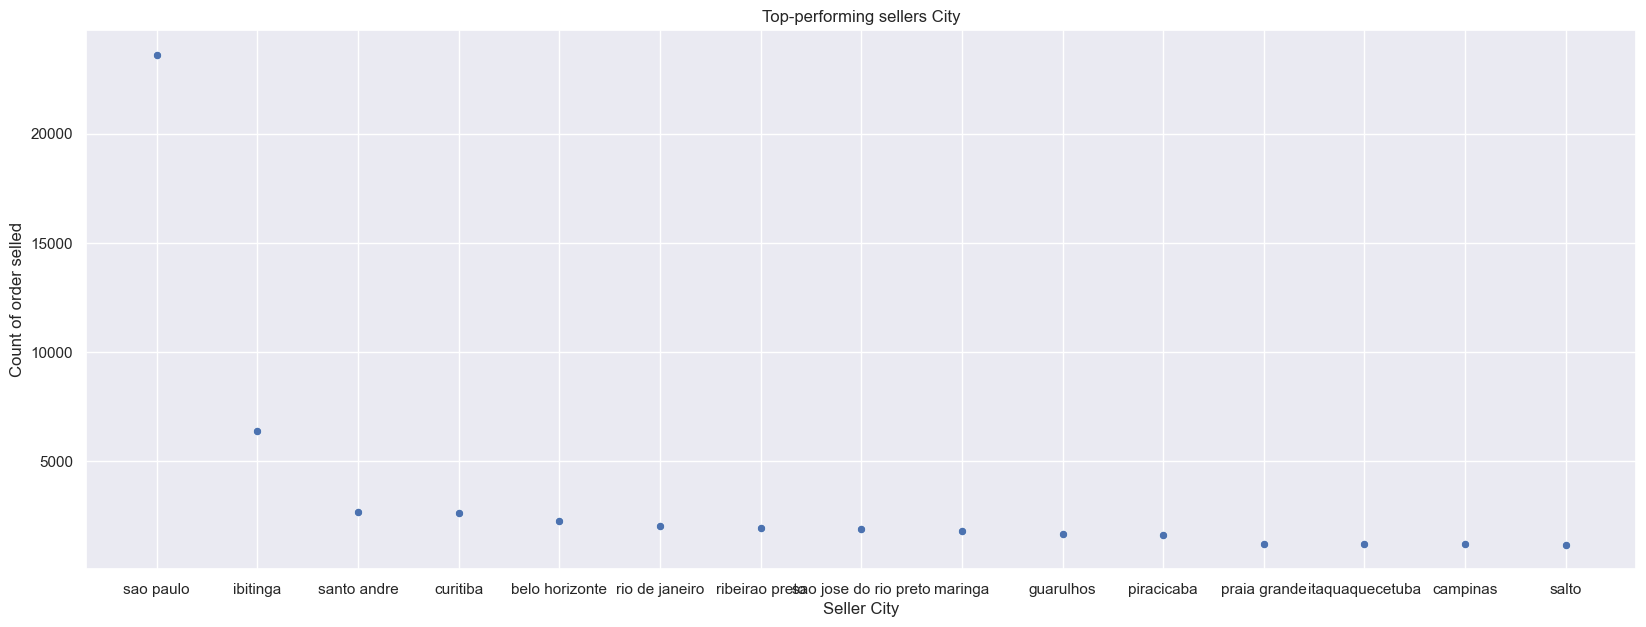

In [93]:
#Top-performing sellers
print('\nTop-performing sellers')
top_sellers = (master_data.groupby('seller_city')['order_id'].size().reset_index().sort_values(by='order_id', ascending=False)).head(15)

plt.title('Top-performing sellers City')
sns.set(rc={"figure.figsize": (20, 7)})
sns.scatterplot(x = 'seller_city', y = 'order_id', data=top_sellers)
plt.xlabel('Seller City')
plt.ylabel('Count of order selled')
plt.show()

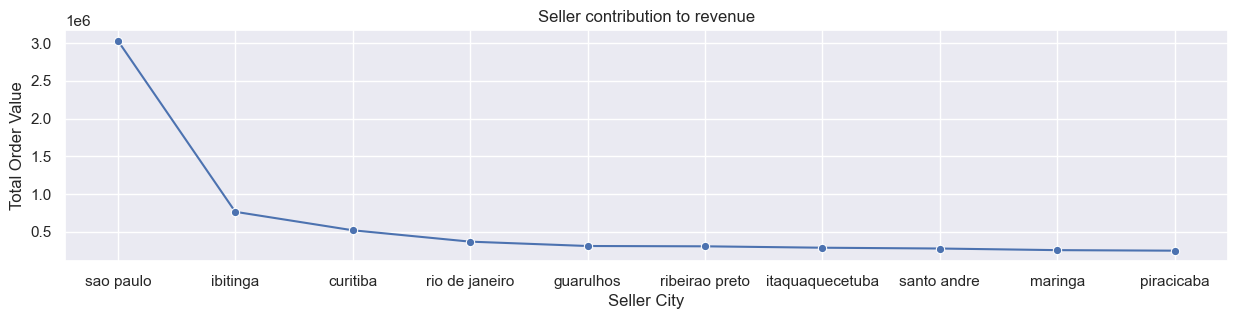

In [107]:
#Seller contribution to revenue
seller_contribution_revenew = (master_data.groupby('seller_city')['total_order_value'].sum().reset_index().sort_values(by='total_order_value', ascending=False)).head(10)
plt.figure(figsize=(15,3))
sns.lineplot(x="seller_city", y="total_order_value", data=seller_contribution_revenew, marker="o")
plt.title("Seller contribution to revenue")
plt.xlabel('Seller City')
plt.ylabel('Total Order Value')
plt.show()

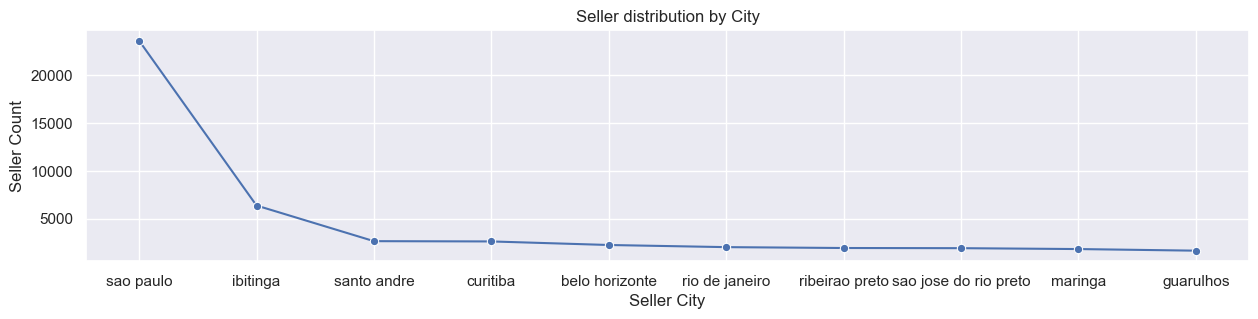

In [106]:
#Seller distribution
seller_distribution = (master_data.groupby('seller_city')['seller_state'].count().reset_index(name='seller_count').sort_values(by='seller_count', ascending=False)).head(10)
plt.figure(figsize=(15,3))
sns.lineplot(x="seller_city", y="seller_count", data=seller_distribution, marker="o")
plt.title("Seller distribution by City")
plt.xlabel('Seller City')
plt.ylabel('Seller Count')
plt.show()

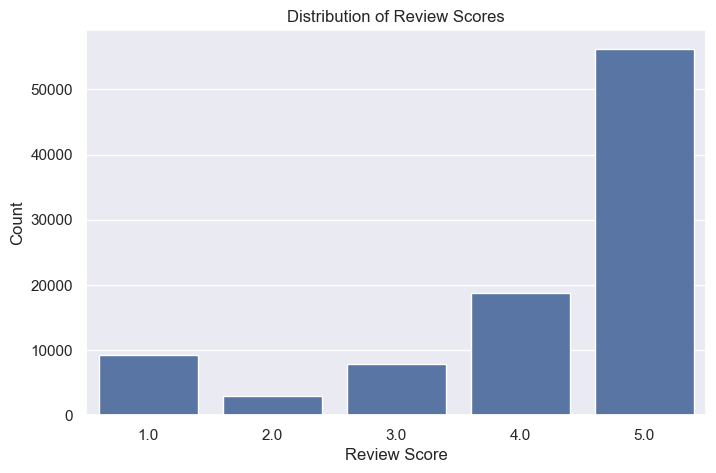

In [108]:
#Distribution of review scores 
plt.figure(figsize=(8,5))
sns.countplot(x='review_score', data=master_data)
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

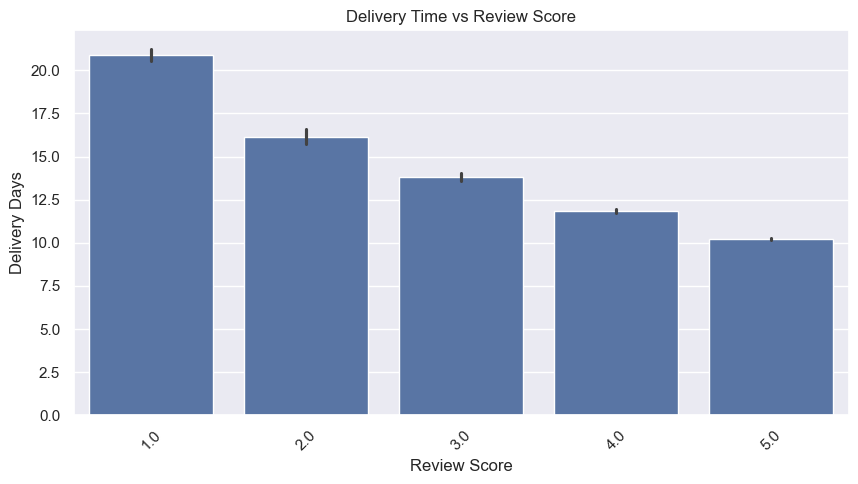

In [115]:
#Relationship between delivery time and ratings 
master_data['delivery_days'] = master_data['delevery_time'].dt.days
plt.figure(figsize=(10,5))
sns.barplot(x='review_score', y='delivery_days', data=master_data)
plt.title("Delivery Time vs Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Days")
plt.xticks(rotation=45)
plt.show()

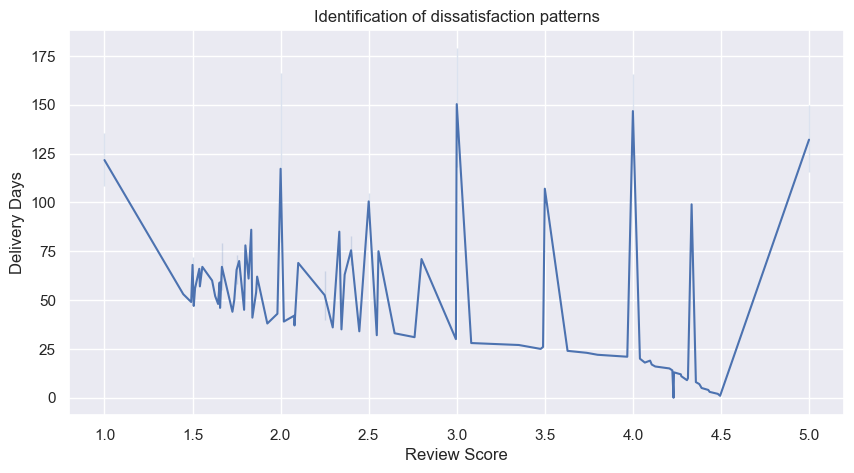

In [120]:
#Identification of dissatisfaction patterns 
avg_rating = master_data.groupby('delivery_days')['review_score'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(x='review_score', y='delivery_days', data=avg_rating)
plt.title("Identification of dissatisfaction patterns")
plt.xlabel("Review Score")
plt.ylabel("Delivery Days")
plt.show()

                                    ###### Data Visualization ########

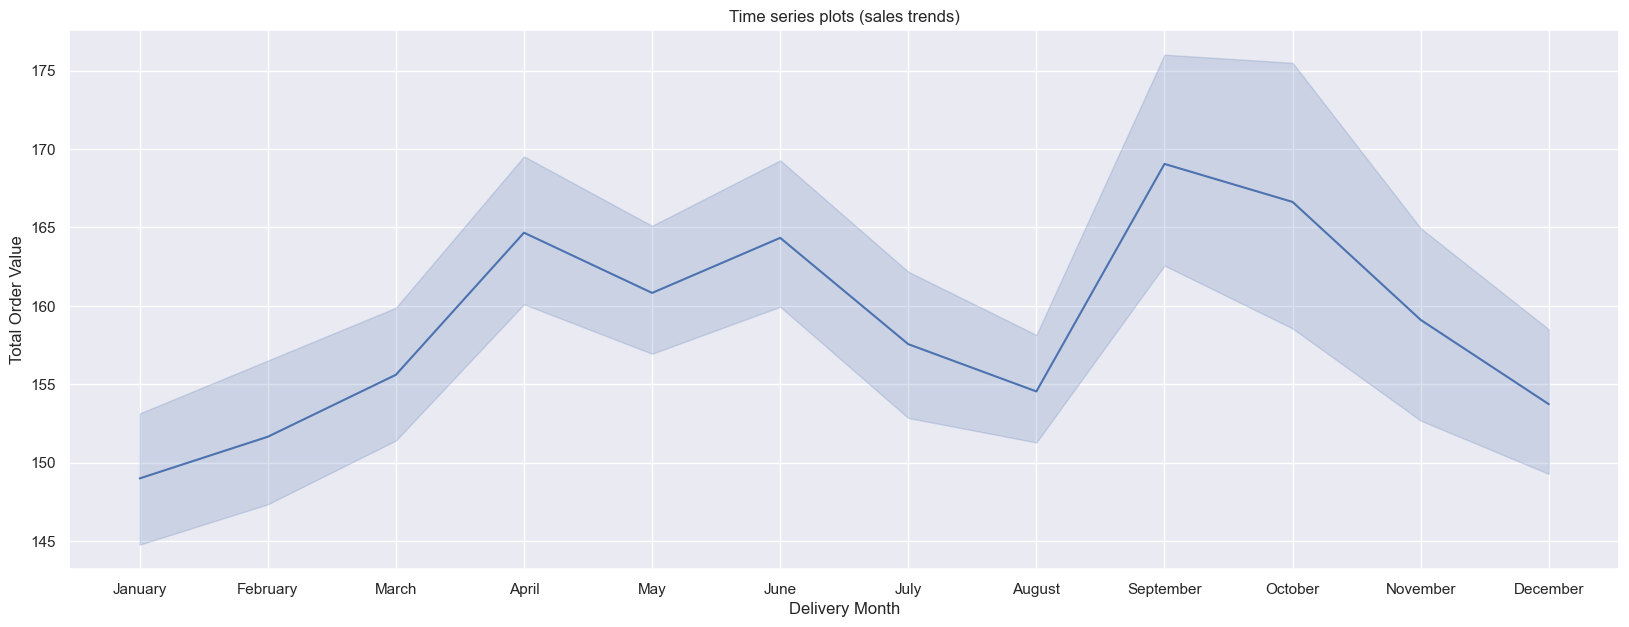

In [123]:
#Time series plots (sales trends)
sns.lineplot(x='delivery_month', y='total_order_value', data=master_data)
plt.title("Time series plots (sales trends)")
plt.xlabel("Delivery Month")
plt.ylabel("Total Order Value")
plt.show()

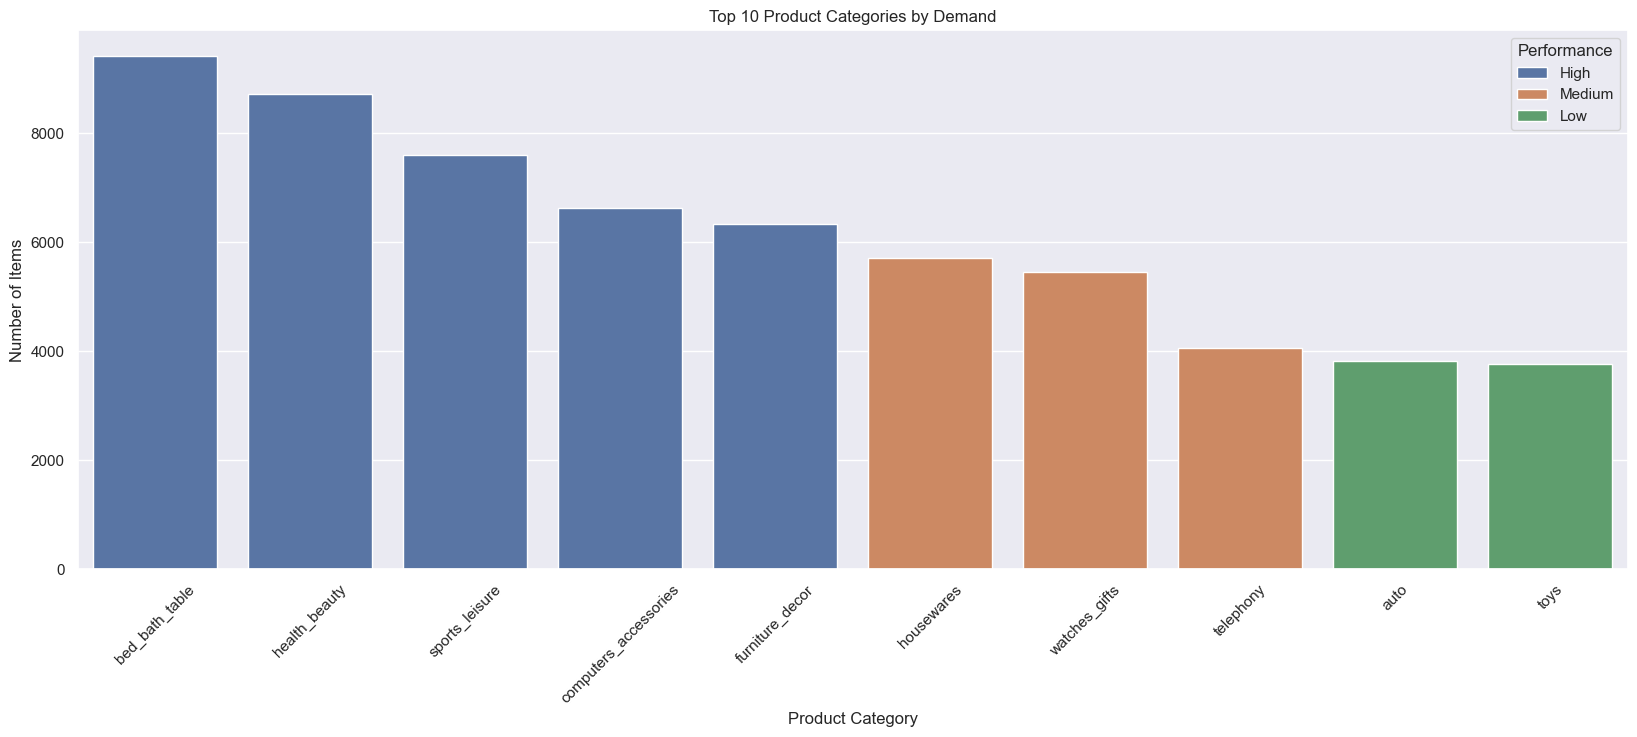

In [126]:
#Bar charts (category performance)
top_categories = product_categories.sort_values(by='number_of_item', ascending=False).head(10)
sns.barplot(x='product_category_name_english', y='number_of_item', data=top_categories, hue='product_performance')
plt.title("Top 10 Product Categories by Demand")
plt.xlabel("Product Category")
plt.ylabel("Number of Items")
plt.xticks(rotation=45)
plt.legend(title="Performance")
plt.show()

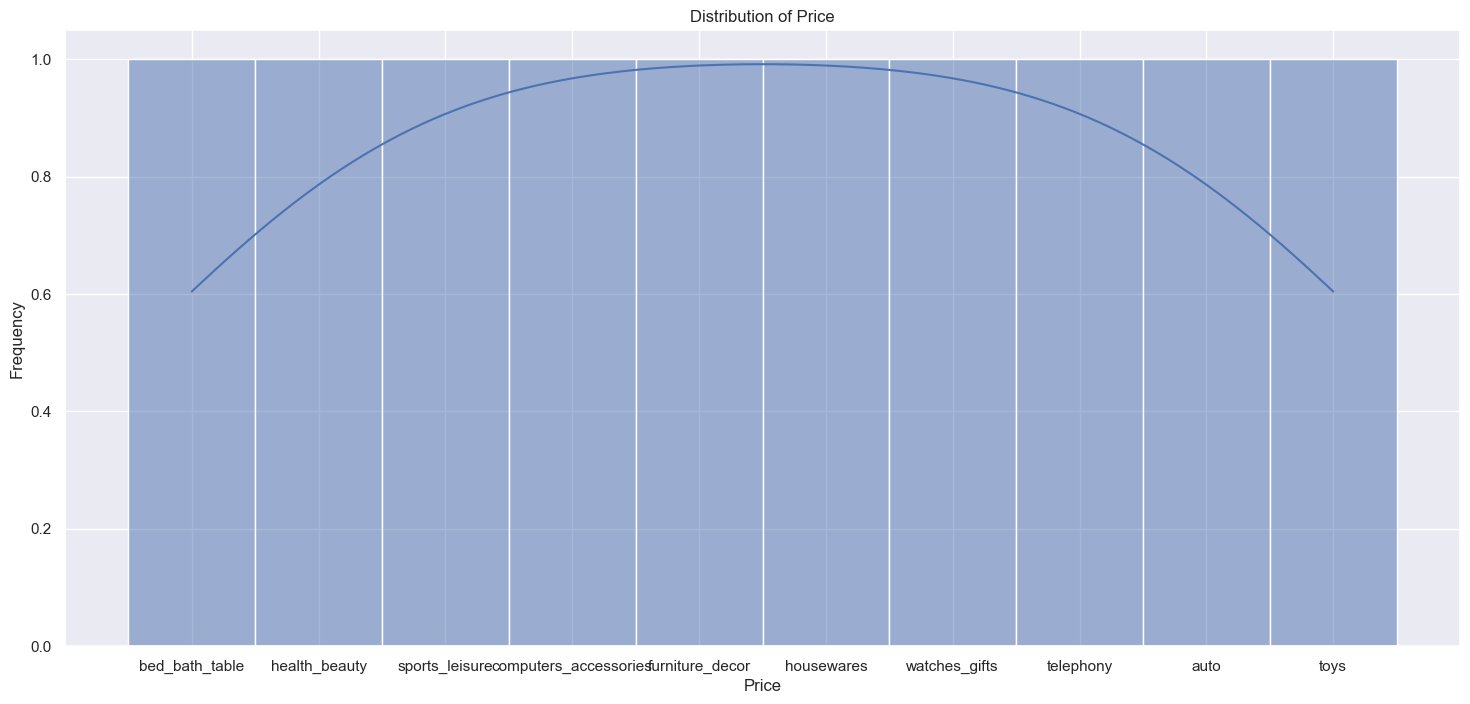

In [127]:
#Histograms (distribution analysis)
plt.figure(figsize=(18,8))
sns.histplot(data=top_categories, x='product_category_name_english', bins=30, kde=True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

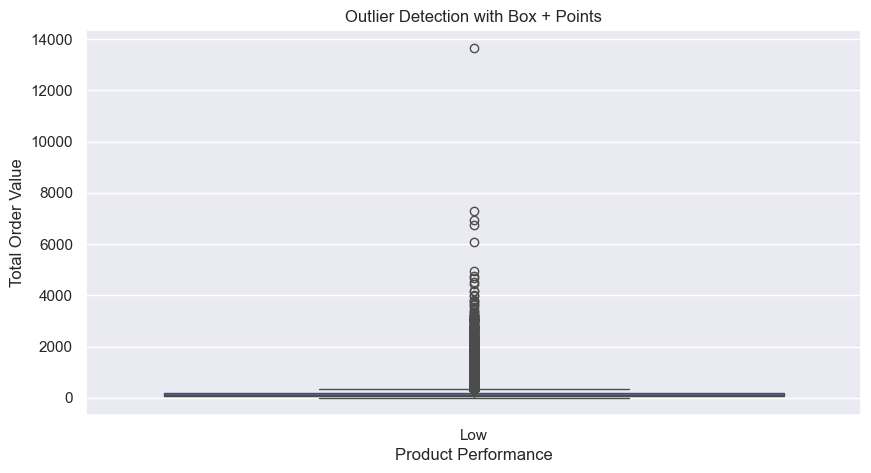

In [133]:
#Box plots (outlier detection)
plt.figure(figsize=(10, 5))
sns.boxplot(x='product_performance', y='total_order_value', data=master_data)
#sns.stripplot(x='total_order_value', y='product_performance', data=master_data, alpha=0.3)
plt.title('Outlier Detection with Box + Points')
plt.xlabel("Product Performance")
plt.ylabel("Total Order Value")
plt.show()

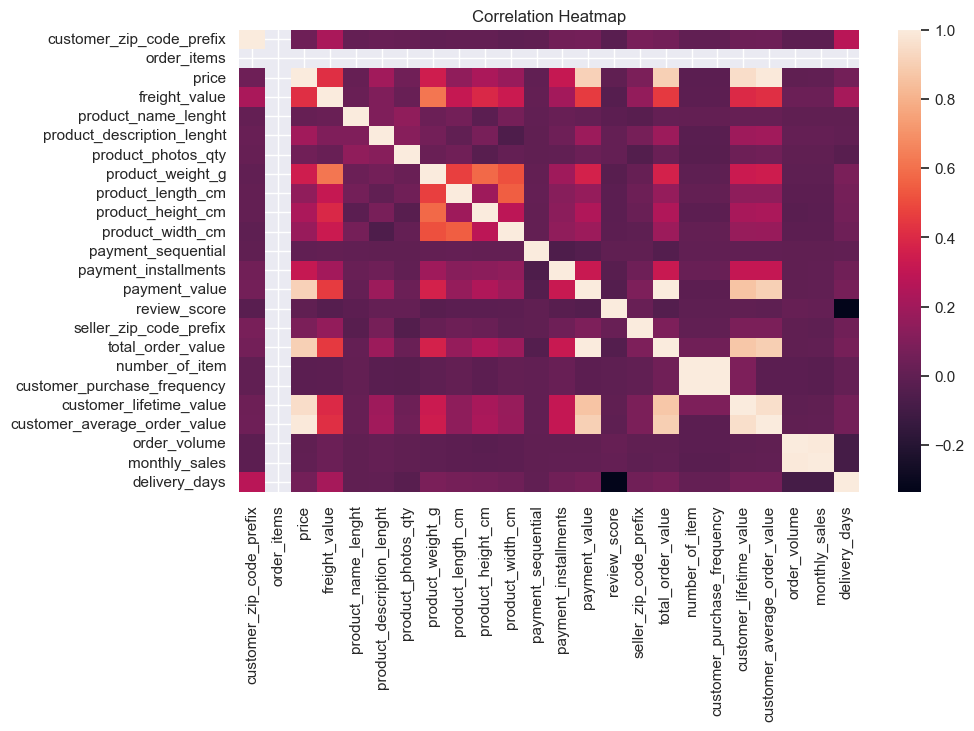

In [129]:
#Heatmaps (correlation analysis)
plt.figure(figsize=(10,6))
corr_matrix = master_data.corr(numeric_only=True)
sns.heatmap(corr_matrix)
plt.title("Correlation Heatmap")
plt.show()

                                    #######Business Insights and Recommendations#########

  delivery_month       revenew  monthly_sales
0      September  2.120248e+09      537588.26
1            May  1.477356e+10     1379417.78
2        January  5.278122e+09      789428.92


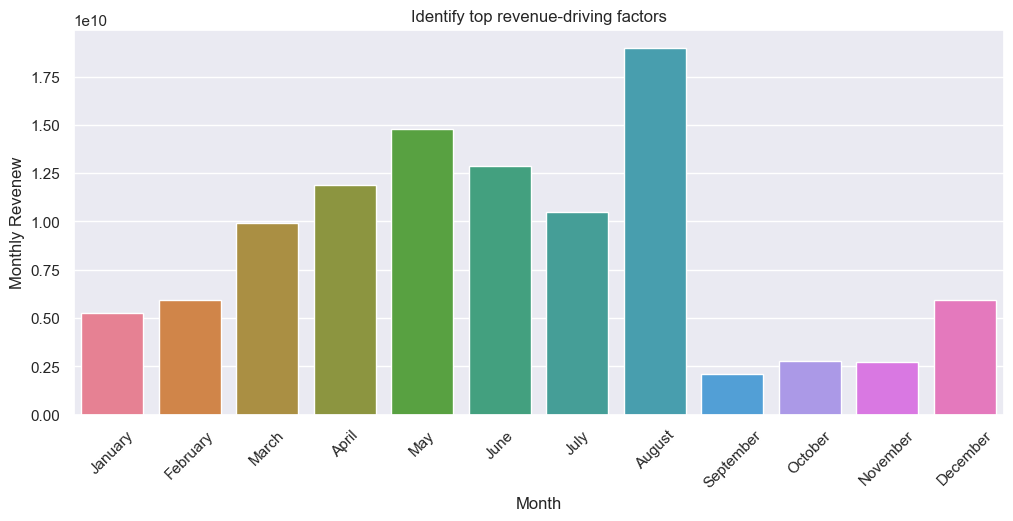

In [151]:
#Identify top revenue-driving factors 
master_data['revenew'] = master_data.groupby('delivery_month', observed=False)['monthly_sales'].transform('sum')
print(master_data[['delivery_month','revenew', 'monthly_sales']].head(3))
plt.figure(figsize=(12,5))
sns.barplot(x='delivery_month', y='revenew', data=master_data, hue='delivery_month')
plt.title("Identify top revenue-driving factors")
plt.xlabel("Month")
plt.ylabel("Monthly Revenew")
plt.xticks(rotation=45)
plt.show()

   customer_lifetime_value  customer_purchase_frequency  \
0                    58.90                            1   
1                   252.78                            1   
2                   199.00                            1   

   customer_average_order_value  
0                         58.90  
1                        126.39  
2                        199.00  


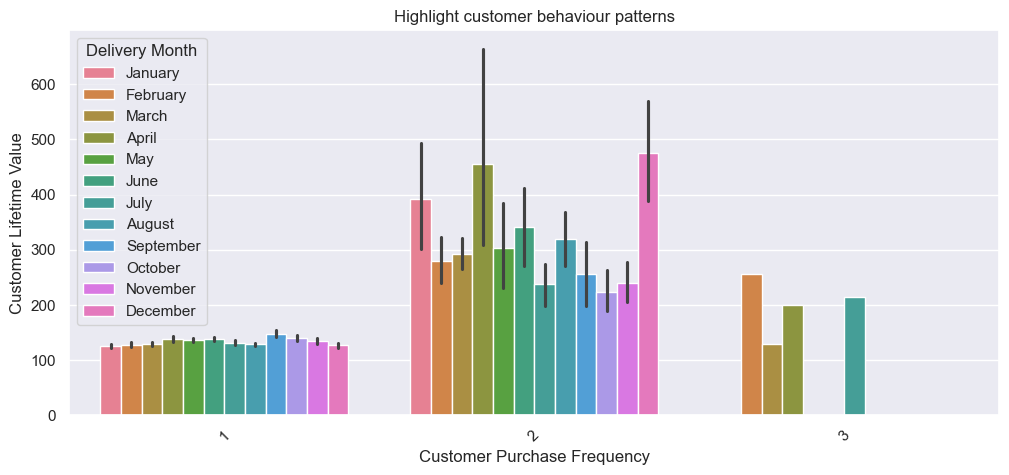

In [152]:
#Highlight customer behaviour patterns 
print(master_data[['customer_lifetime_value','customer_purchase_frequency', 'customer_average_order_value']].head(3))
plt.figure(figsize=(12,5))
sns.barplot(x='customer_purchase_frequency', y='customer_lifetime_value', data=master_data, hue='delivery_month')
plt.title("Highlight customer behaviour patterns")
plt.xlabel("Customer Purchase Frequency")
plt.ylabel("Customer Lifetime Value")
plt.xticks(rotation=45)
plt.legend(title="Delivery Month")
plt.show()

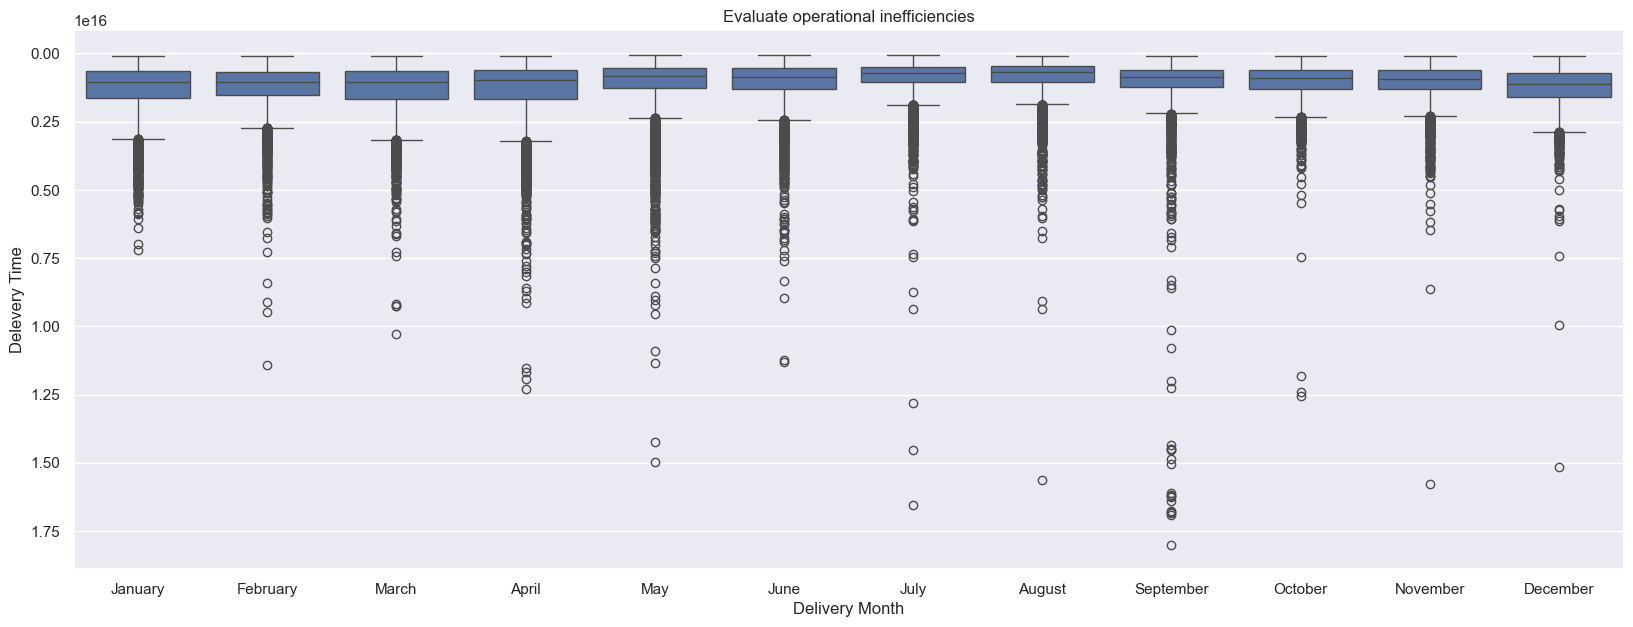

seller_id
df683dfda87bf71ac3fc63063fba369d   189 days 20:43:00
8e670472e453ba34a379331513d6aab1    86 days 00:02:00
8d92f3ea807b89465643c219455e7369    70 days 20:08:00
586a871d4f1221763fddb6ceefdeb95e    68 days 14:54:00
4fb41dff7c50136976d1a5cf004a42e2    66 days 18:06:40
Name: delevery_time, dtype: timedelta64[ns]

Revenue lost due to cancellations: 23755857102.869995

 customer_city
sao paulo         14798
rio de janeiro     6463
belo horizonte     2652
brasilia           2051
curitiba           1470
Name: count, dtype: int64

 seller_city
sao paulo         23621
ibitinga           6375
santo andre        2646
curitiba           2617
belo horizonte     2245
Name: count, dtype: int64


In [170]:
#Evaluate operational inefficiencies 
sns.boxplot(x='delivery_month', y='delevery_time', data=master_data)
plt.title('Evaluate operational inefficiencies')
plt.xlabel("Delivery Month")
plt.ylabel("Delevery Time")
plt.show()

seller_delay = (master_data.groupby('seller_id')['delevery_time'].mean().sort_values(ascending=False))
print(seller_delay.head(5))

cancelled = master_data[master_data['order_status'] == 'canceled']
loss = cancelled['revenew'].sum()
print("\nRevenue lost due to cancellations:", loss)

orders_by_city = master_data['customer_city'].value_counts()
sellers_by_city = master_data['seller_city'].value_counts()

print('\n', orders_by_city.head())
print('\n', sellers_by_city.head())

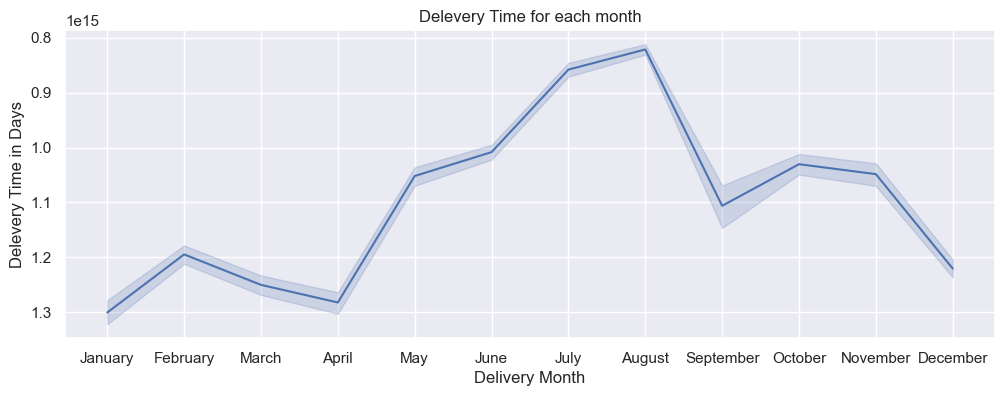

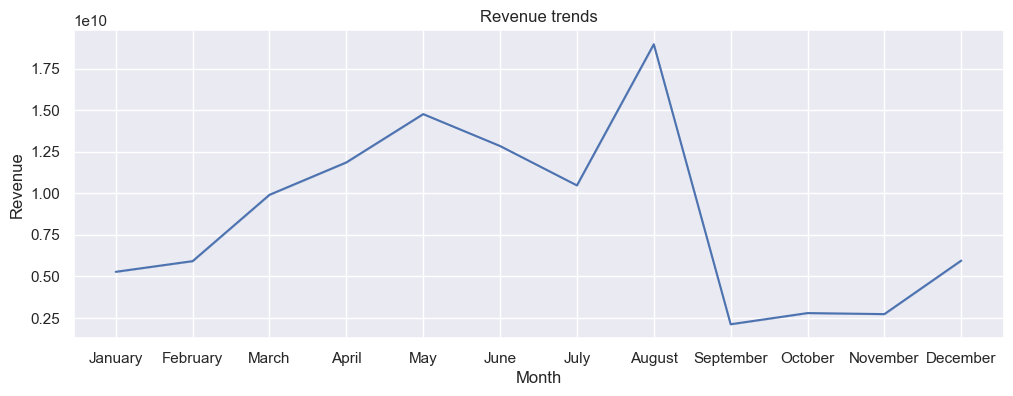

In [177]:
#Provide strategic recommendations
plt.figure(figsize=(12,4))
sns.lineplot(x='delivery_month', y='delevery_time', data=master_data)
plt.title("Delevery Time for each month")
plt.xlabel("Delivery Month")
plt.ylabel("Delevery Time in Days")
plt.show()

#Revenue trends
plt.figure(figsize=(12,4))
sns.lineplot(x='delivery_month', y='revenew', data=master_data)
plt.title("Revenue trends")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()
